<a href="https://colab.research.google.com/github/zyang91/ai-sustainbility-assignment/blob/main/assignment4/assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Land Use and Land Cover Classification using Pytorch

Modified by Xiaojiang Li, UPenn based on Climate AI Summer school tutorial.

In this tutorial, we are going to build our very own neural network for simple tasks.


More reference:
- Stanford, Convolution Neural Network for Visual Recognition
https://www.youtube.com/playlist?list=PL3FW7Lu3i5JvHM8ljYj-zLfQRF3EO8sYv

- Neural networks 3Blue1Brown, https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi


## Before this tutorial, please finish the tutorial of Training a Classifier in PyTorch first.


https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

<a name="overview"></a>
# Overview
This tutorial covers an introduction to image classification using Pytorch for land use and land cover (LULC) mapping.

Specifically, you will learn how to:
- classify satellite images into 10 LULC categories using the [EuroSAT dataset](https://arxiv.org/abs/1709.00029)
- fine-tune a Resnet-50 CNN model for image classification
- save and load trained models in Pytorch




<a name="software-requirements"></a>
# Software Requirements

This notebook requires Python >= 3.7. The following libraries are required:
*   tqdm
*   pandas
*   numpy
*   matplotlib
*   pytorch

## Enabling GPU in Google Colab
Before we start, you will need access to a GPU.  Fortunately, Google Colab provides free access to computing resources including GPUs. The GPUs currently available in Colab include Nvidia K80s, T4s, P4s and P100s. Unfortunately, there is no way to choose what type of GPU you can connect to in Colab. [See here for information](https://research.google.com/colaboratory/faq.html#gpu-availability).

To enable GPU in Google Colab:
1. Navigate to Edit→Notebook Settings or Runtime→Change Runtime Type.
2. Select GPU from the Hardware Accelerator drop-down.

In [ ]:
# Standard libraries
import os
import random
from tqdm.notebook import tqdm

# Data manipulation and visualization
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns
import pandas as pd
import numpy as np

# Deep Learning libraries
import torch
import torchvision
import torchsummary
from torch.utils import data
from torchvision import datasets, models, transforms

# Set seed for reproducibility
SEED = 42
np.random.seed(SEED)

## Google Colab GPU
Check that the GPU  enabled in your colab notebook by running the cell below.

In [ ]:
# Check is GPU is enabled
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

# Get specific GPU model
if str(device) == "cuda:0":
  print("GPU: {}".format(torch.cuda.get_device_name(0)))

Device: cuda:0
GPU: Tesla T4


## Mount Drive

Mounting the drive will allow the Google Colab notebook to load and access files from your Google drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


<a name="data-description"></a>
# Data Description

In this section, you will learn how to:
- Download the EuroSAT dataset into your Google Drive
- Generate the train and test sets by splitting the EuroSAT dataset
- Visualize a sample of the images and their LULC labels

## EuroSAT Dataset
The [EuroSAT dataset](https://github.com/phelber/EuroSAT) contains 27,000 labelled 64x64 pixel Sentinel-2 satellite image patches with 10 different LULC categories. Both RGB and multi-spectral (MS) images are available for download. For simplicity, we will focus on RGB image classification.

Here we are going to use several `shell` script to download the data and unzip it.

In [ ]:
# !wget http://madm.dfki.de/files/sentinel/EuroSAT.zip -O EuroSAT.zip
!wget https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1 -O EuroSAT.zip

!unzip -q EuroSAT.zip -d 'EuroSAT/'
!rm EuroSAT.zip

--2026-09-29 17:35:51--  https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94658721 (90M) [application/octet-stream]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  90.27M  2.07MB/s    in 65s     

2026-09-29 17:36:58 (1.38 MB/s) - ‘EuroSAT.zip’ saved [94658721/94658721]



### Alternative Data Download using `torchvision.datasets`

The previous download method failed because the Zenodo link was not accessible. Instead, we can leverage the `torchvision.datasets.EuroSAT` class, which provides a convenient and reliable way to download and prepare the EuroSAT dataset. This method automatically handles downloading, extraction, and organization of the dataset.

In [ ]:
# Download and load the EuroSAT dataset using torchvision.datasets
# root='./EuroSAT/' specifies the directory where the data will be stored
# download=True ensures the dataset is downloaded if not already present
# transform=None is set for now, as transforms will be applied later for train/val/test splits

# Ensure the data directory exists
import os
data_dir = './EuroSAT/'
if not os.path.exists(data_dir):
    os.makedirs(data_dir)

dataset = datasets.EuroSAT(root=data_dir, download=True, transform=None)

# Verify the dataset has been loaded
print(f"Dataset loaded successfully with {len(dataset)} images.")

# Optionally, you might want to adjust the `data_dir` to point to the correct subdirectory
# if `EuroSAT` creates a nested structure like EuroSAT/eurosat/2750.
# The current code in `TM7hyGz3Ry8e` expects './EuroSAT/2750/'.
# We can explicitly set the data_dir for ImageFolder to this path if needed.
# For now, let's assume `datasets.EuroSAT` puts the images directly under `data_dir` or a common subdirectory.
# If `ImageFolder` fails in cell `TM7hyGz3Ry8e` because of path, we'll address it there.


Dataset loaded successfully with 27000 images.


## Generate Train and Test Sets

### Create Custom Dataset Class
In Pytorch, the `Dataset` class allows you to define a custom class to load the input and target for a dataset.  We will use this capability to load in our inputs in the form of RGB satellite images along with their corresponding labels. Later we'll learn how to apply necessary image transformations (see next section).

In [ ]:
class EuroSAT(data.Dataset):
    def __init__(self, dataset, transform=None):
        self.dataset = dataset
        self.transform = transform

    def __getitem__(self, index):
        # Apply image transformations
        if self.transform:
            x = self.transform(dataset[index][0])
        else:
            x = dataset[index][0]

        # Get class label
        y = dataset[index][1]
        return x, y

    def __len__(self):
        return len(dataset)


### Data Augmentation

Data augmentation is a  technique that randomly applies image transformations, e.g. crops, horizontal flips, and vertical flips, to the input images during model training. These perturbations reduce the neural network's overfitting to the training dataset, and they allow it to generalize better to the unseen test dataset.
<br><br>
<center> <br>
<center> <img src="https://miro.medium.com/v2/resize:fit:1100/format:webp/0*ttoU2HOnBI8cb9Y2.png" width="400"/>
<br>
<font size=2>Image Source: <a href="https://pranjal-ostwal.medium.com/data-augmentation-for-computer-vision-b88b818b6010">https://pranjal-ostwal.medium.com/data-augmentation-for-computer-vision-b88b818b6010</a></a> </font>
<br>
</center>
</center>
<br>
<font size=2>Image Source: Ahmad, Jamil & Muhammad, Khan & Baik, Sung. (2017). Data augmentation-assisted deep learning of hand-drawn partially colored sketches for visual search. PLOS ONE. 12. e0183838. 10.1371/journal.pone.0183838. </font>
<br>


### Image Normalization
Additionally, in the cell below, the `transforms.Normalize` method normalizes each of the three channels to the given means and standard deviations defined in the `imagenet_mean` and `imagenet_std` variables. ImageNet is a large training dataset of images and labels.  Later in this tutorial, we will be using a model pre-trained on this dataset.  In order to use this pre-trained model for our LULC dataset, we need to ensure that the input dataset is normalized to have the same statistics (mean and standard deviation) as ImageNet.

<br>
<center> <img src="https://cv.gluon.ai/_images/imagenet_banner.jpeg" width="400"/>
<br>
<font size=2>Image Source: <a href=" https://cv.gluon.ai/build/examples_datasets/imagenet.html">https://cv.gluon.ai/build/examples_datasets/imagenet.html</a></font>
<br>
</center>

Existing research has found that using models pretrained on massive datasets, such as ImageNet, improves accuracy when applying these neural networks to new datasets.  Pre-trained models serve as excellent generic feature extractors.  [Please read here for more information](https://pytorch.org/tutorials/beginner/finetuning_torchvision_models_tutorial.html).

In [ ]:
input_size = 224
imagenet_mean, imagenet_std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(input_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

test_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


### Load EuroSAT Dataset
Let's start by loading the EuroSAT dataset using torch's `ImageFolder` class.

`ImageFolder` is a generic data loader where the images are arranged in this way:

```
    data
    └───AnnualCrop
    │   │   AnnualCrop_1.jpg
    │   │   AnnualCrop_2.jpg
    │   │   AnnualCrop_3.jpg
    │   │   ...
    └───Forest
    │   │   Forest_1.jpg
    │   │   Forest_2.jpg
    │   │   Forest_3.jpg
    │   │   ...
```


In [ ]:
# Load the dataset
data_dir = './EuroSAT/EuroSAT_RGB/'
dataset = datasets.ImageFolder(data_dir)

# Get LULC categories
class_names = dataset.classes
print("Class names: {}".format(class_names))
print("Total number of classes: {}".format(len(class_names)))

Class names: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total number of classes: 10


In [ ]:
# Re-reading and reloading the EuroSAT dataset
data_dir = './EuroSAT/EuroSAT_RGB/'
dataset = datasets.ImageFolder(data_dir)

print(f"Dataset re-loaded successfully. Classes: {dataset.classes}")
print(f"Total images: {len(dataset)}")

### Split into Train, Validation, and Test Sets
Here, we split the dataset into a train set and test set. The training set will be 70% of the Eurosat dataset, randomly selected. We set aside 15% of the dataset as our validation set and the remaining 15% as our test set.

In [ ]:
# Apply different transformations to the training and test sets
train_data = EuroSAT(dataset, train_transform)
val_data = EuroSAT(dataset, val_transform)
test_data = EuroSAT(dataset, test_transform)

# Randomly split the dataset into 70% train / 15% val / 15% test
# by subsetting the transformed train and test datasets
train_size = 0.70
val_size = 0.15
indices = list(range(int(len(dataset))))
train_split = int(train_size * len(dataset))
val_split = int(val_size * len(dataset))
np.random.shuffle(indices)

train_data = data.Subset(train_data, indices=indices[:train_split])
val_data = data.Subset(val_data, indices=indices[train_split: train_split+val_split])
test_data = data.Subset(test_data, indices=indices[train_split+val_split:])
print("Train/val/test sizes: {}/{}/{}".format(len(train_data), len(val_data), len(test_data)))

Train/val/test sizes: 18900/4050/4050


Finally, we use `torch`'s `DataLoader` class to create a dataloader.  The dataloader manages fetching samples from the datasets (it can even fetch them in parallel using `num_workers`) and assembles batches of the datasets.

In [ ]:
num_workers = 2
batch_size = 16

train_loader = data.DataLoader(
    train_data, batch_size=batch_size, num_workers=num_workers, shuffle=True
)
val_loader = data.DataLoader(
    val_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)
test_loader = data.DataLoader(
    test_data, batch_size=batch_size, num_workers=num_workers, shuffle=False
)

## Visualize Data

In the cell below, we will visualize a batch of the dataset.  The cell visualizes the input to the neural network (the RGB image) along with the associated label.

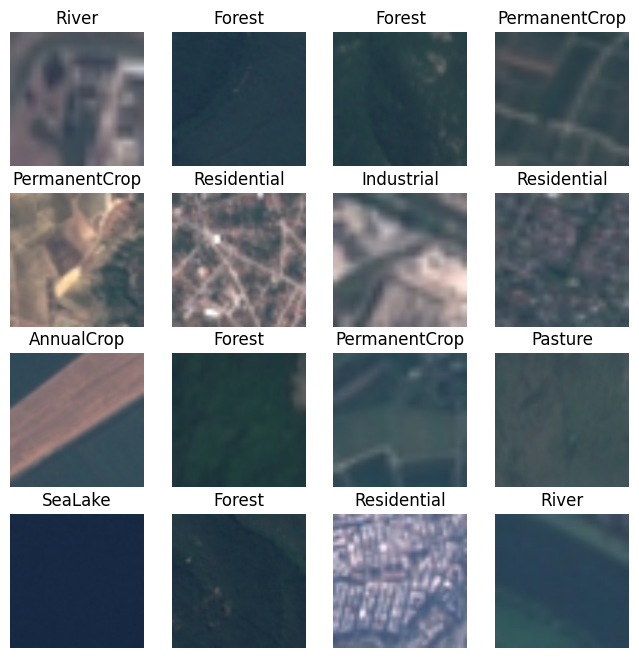

In [ ]:
n = 4
inputs, classes = next(iter(train_loader))
fig, axes = plt.subplots(n, n, figsize=(8, 8))

for i in range(n):
  for j in range(n):
    image = inputs[i * n + j].numpy().transpose((1, 2, 0))
    image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

    title = class_names[classes[i * n + j]]
    axes[i, j].imshow(image)
    axes[i, j].set_title(title)
    axes[i, j].axis('off')

# Exploratory Data Analysis

Next, let's explore our dataset a little bit more.  In particular, how many images of each class are included?

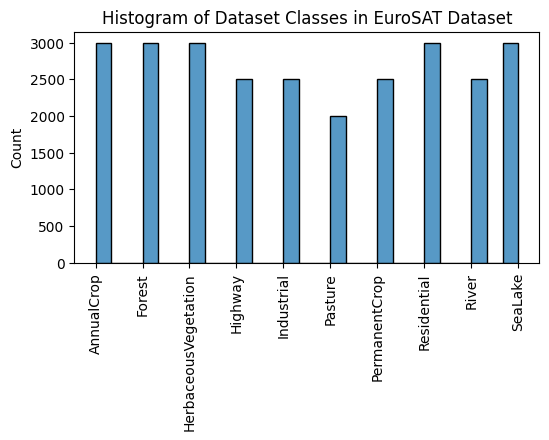

In [ ]:
plt.figure(figsize=(6, 3))
hist = sns.histplot(dataset.targets)

hist.set_xticks(range(len(dataset.classes)))
hist.set_xticklabels(dataset.classes, rotation=90)
hist.set_title('Histogram of Dataset Classes in EuroSAT Dataset')

plt.show()

#### Build a simple CNN model for image classification

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3)  # Input: 3 channels (RGB)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)  # Output: 64 filters

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)  # Downsample by 2x

        # Adaptive layer to compute feature size
        self.flatten_size = None  # This will be set dynamically later

        # Fully connected layers (Initialized later)
        self.fc1 = None
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, 10)  # EuroSAT has 10 classes

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # After conv1 + pooling
        x = self.pool(self.relu(self.conv2(x)))  # After conv2 + pooling

        # Dynamically compute feature map size
        if self.flatten_size is None:
            self.flatten_size = x.shape[1] * x.shape[2] * x.shape[3]
            self.fc1 = nn.Linear(self.flatten_size, 128).to(x.device)  # Adjust FC layer dynamically

        x = x.view(-1, self.flatten_size)  # Flatten dynamically
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Initialize the model
model = SimpleCNN()
print(model)


SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=64, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


#### Define the loss function

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.utils.data import DataLoader
import numpy as np

# # Initialize model
# model = SimpleCNN()

# Set loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Since it's a classification task
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


#### Start the training process

In [ ]:
# Set training parameters
epochs = 40  # Number of training epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available

# Move model to device
model.to(device)

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_total_correct = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        # Calculate statistics
        _, preds = torch.max(outputs, 1)

        # Calculate running loss and accuracy
        # running_loss += loss.item()
        running_loss += loss.item() * images.size(0)
        running_total_correct += torch.sum(preds == labels)
    # Calculate epoch loss and accuracy
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_accuracy = (running_total_correct / len(train_loader.dataset)) * 100
    print(f"Train Loss: {epoch_loss:.2f}; Training Accuracy: {epoch_accuracy:.2f}")


    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Print results
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader):.4f}, "
          f"Val Loss: {val_loss/len(val_loader):.4f}, "
          f"Val Acc: {100 * correct / total:.2f}%")
print("Training complete!")


Train Loss: 2.29; Training Accuracy: 18.36
Epoch 1/40 - Train Loss: 36.6344, Val Loss: 2.2777, Val Acc: 21.93%
Train Loss: 2.26; Training Accuracy: 21.41
Epoch 2/40 - Train Loss: 36.1785, Val Loss: 2.2431, Val Acc: 22.89%
Train Loss: 2.22; Training Accuracy: 22.30
Epoch 3/40 - Train Loss: 35.4767, Val Loss: 2.1892, Val Acc: 24.12%
Train Loss: 2.16; Training Accuracy: 23.14
Epoch 4/40 - Train Loss: 34.5664, Val Loss: 2.1290, Val Acc: 23.98%
Train Loss: 2.10; Training Accuracy: 22.84
Epoch 5/40 - Train Loss: 33.6220, Val Loss: 2.0683, Val Acc: 23.19%
Train Loss: 2.05; Training Accuracy: 22.57
Epoch 6/40 - Train Loss: 32.7825, Val Loss: 2.0163, Val Acc: 24.22%
Train Loss: 2.01; Training Accuracy: 23.36
Epoch 7/40 - Train Loss: 32.0814, Val Loss: 1.9773, Val Acc: 24.47%
Train Loss: 1.97; Training Accuracy: 24.10
Epoch 8/40 - Train Loss: 31.5711, Val Loss: 1.9465, Val Acc: 24.91%
Train Loss: 1.95; Training Accuracy: 24.97
Epoch 9/40 - Train Loss: 31.1416, Val Loss: 1.9224, Val Acc: 25.23%
T

#### Test the trainned model on one image

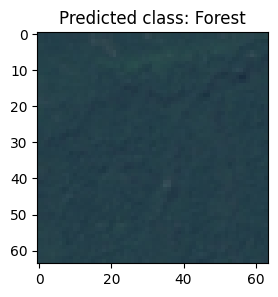

In [ ]:
from PIL import Image
image_path = './EuroSAT/EuroSAT_RGB/Forest/Forest_2.jpg'
image = Image.open(image_path)

# Transform image
input = test_transform(image).to(device) # Move input to GPU

# Predict on sample
output = model(input.unsqueeze(0))

# Get corresponding class label
_, pred = torch.max(output, 1)
pred = class_names[pred[0]]

# Visualize results
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(image)
ax.set_title("Predicted class: {}".format(pred));


#### The model accuracy is not high, let make the model a little bit more complicated.

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)  # Increased filters and added padding
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # Increased filters and added padding
        self.conv3 = nn.Conv2d(128, 256, kernel_size=3, padding=1)  # Added another convolutional layer

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)  # Downsample by 2x

        # Adaptive layer to compute feature size
        self.flatten_size = None  # This will be set dynamically later

        # Fully connected layers (Initialized later)
        self.fc1 = None
        self.fc2 = nn.Linear(512, 10)  # EuroSAT has 10 classes, adjusted input size

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # After conv1 + pooling
        x = self.pool(self.relu(self.conv2(x)))  # After conv2 + pooling
        x = self.pool(self.relu(self.conv3(x)))  # After conv3 + pooling

        # Dynamically compute feature map size
        if self.flatten_size is None:
            self.flatten_size = x.shape[1] * x.shape[2] * x.shape[3]
            self.fc1 = nn.Linear(self.flatten_size, 512).to(x.device)  # Adjust FC layer dynamically

        x = x.view(-1, self.flatten_size)  # Flatten dynamically
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# Initialize the model
model = SimpleCNN()
print(model)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# from torch.utils.data import DataLoader
import numpy as np

# # Initialize model
# model = SimpleCNN()

# Set loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Since it's a classification task
optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)


In [ ]:
# Set training parameters
epochs = 20  # Number of training epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use GPU if available

# Move model to device
model.to(device)

# Training loop
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Print results
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {running_loss/len(train_loader):.4f}, "
          f"Val Loss: {val_loss/len(val_loader):.4f}, "
          f"Val Acc: {100 * correct / total:.2f}%")

print("Training complete!")



## Let's try a popular pre-trained model

First, let's instatiate the model.  To start, we will use a standard neural network architecture, called ResNet50. Based on [the work by Helber et al.](https://arxiv.org/pdf/1709.00029.pdf), ResNet-50 has been shown to work well for LULC classification on the EuroSAT

### ResNet-50
<b>Recall</b>: Deep neural networks are difficult to train due to the problem of vanishing or exploding gradients (repeated multiplication making the gradient infinitively small). ResNet solves this by using shortcut connections that connect activation from an earlier layer to a further layer by skipping one or more layers as shown below. This allows for gradients to propagate to the deeper layers before they can be reduced to small or zero values.
<br><br>

<center> <img src="https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/images/resnet50.png" width="600"/><br>
Image source: <a href="https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/">https://jananisbabu.github.io/ResNet50_From_Scratch_Tensorflow/  </a>
</center>
<br>

Note that when we load the model, we set the `weights=models.ResNet50_Weights.DEFAULT` to indicate that the loaded model should be already pre-trained on the Imagenet dataset. We also modify the final layer so that the output matches the number of classes in our dataset.

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)
# torchsummary.summary(model, (3, 224, 224))

## Model Training and Evaluation

We can now proceed to model training and evaluation.

This section has three major parts:

1. Specify the criterion, optimizer, and hyperparameters (e.g. n_epochs, learning rate, etc.).
2. Train the model on the training set by updating its weights to minimize the loss function.
3. Evaluate the model on the test set to observe performance on new, unseen data.
4. Repeat steps 2 and 3 `n_epochs` times.

### Cross Entropy Loss
We define our loss as the cross-entropy loss, which measures the performance of a classification model whose output is a probability value between 0 and 1. Cross-entropy loss increases as the predicted probability diverges from the actual label. ([Source](https://ml-cheatsheet.readthedocs.io/en/latest/loss_functions.html))

For two classes, it is computed as:

$−ylog(p)-(1−y)log(1−p)$

For multiclass classification with $M$ classes, it is defined as:

$−\sum_{c=1}^{M}y_{o,c}log(p_{o,c})$

where

- $M$ - number of classes (dog, cat, fish)
- $log$ - the natural log
- $y_{o,c}$ - binary indicator (0 or 1) if class label $c$ is the classification for observation $o$
- $p_{o,c}$- predicted probability observation $o$ is of class $c$

### Stochastic Gradient Descent
Remember that the goal of stochastic gradient descent (SGD) is to minimize the loss function. To do this, it computes the slope (gradient) of the loss function at the current point and moves in the opposite direction of the slope towards the steepest descent.
<center> <img src="https://miro.medium.com/max/1400/1*P7z2BKhd0R-9uyn9ThDasA.png" width="350"/><br>Image source:
<a href="https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a">https://towardsdatascience.com/batch-mini-batch-stochastic-gradient-descent-7a62ecba642a</a>
</center>
<br>

In [ ]:
# Specify number of epochs and learning rate
n_epochs = 10
lr = 1e-3

# Specify criterion and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

Next. let's create our training function.

In [ ]:
def train(model, dataloader, criterion, optimizer):
  model.train()

  running_loss = 0.0
  running_total_correct = 0.0

  for i, (inputs, labels) in enumerate(tqdm(dataloader)):
    inputs = inputs.to(device)
    labels = labels.to(device)

    # Zero the parameter gradients
    # Clear off previous weights in order
    # to obtain updated weights.
    optimizer.zero_grad()

    # Forward pass
    outputs = model(inputs)

    # Compute the loss
    loss = criterion(outputs, labels)

    # Compute the gradients wrt the loss
    loss.backward()

    # Update the weights based on the
    # internally stored gradients
    optimizer.step()

    # Calculate statistics
    _, preds = torch.max(outputs, 1)

    # Calculate running loss and accuracy
    running_loss += loss.item() * inputs.size(0)
    running_total_correct += torch.sum(preds == labels)

  # Calculate epoch loss and accuracy
  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100
  print(f"Train Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

  return epoch_loss, epoch_accuracy

Next, let's define the model evaluation function.

In [ ]:
def evaluate(model, dataloader, criterion, phase="val"):
  model.eval()

  running_loss = 0.0
  running_total_correct = 0.0

  for i, (inputs, labels) in enumerate(tqdm(dataloader)):
    inputs = inputs.to(device)
    labels = labels.to(device)

    with torch.set_grad_enabled(False):
      outputs = model(inputs)
      loss = criterion(outputs, labels)
      _, preds = torch.max(outputs, 1)

    running_loss += loss.item() * inputs.size(0)
    running_total_correct += torch.sum(preds == labels)

  # Calculate epoch loss and accuracy
  epoch_loss = running_loss / len(dataloader.dataset)
  epoch_accuracy = (running_total_correct / len(dataloader.dataset)) * 100
  print(f"{phase.title()} Loss: {epoch_loss:.2f}; Accuracy: {epoch_accuracy:.2f}")

  return epoch_loss, epoch_accuracy

Putting it all together, we define the `fit` function for training and evaluating the model on the training set and validation set, respectively.

In [ ]:
def fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer):
  # Keep track of the best loss and
  # best model weights with the lowest loss
  best_loss = np.inf
  best_model = None

  # Train and test over n_epochs
  for epoch in range(n_epochs):
    print("Epoch {}".format(epoch+1))
    train(model, train_loader, criterion, optimizer)
    val_loss, _ = evaluate(model, val_loader, criterion)

    if val_loss < best_loss:
      best_loss = val_loss
      best_model = model

  return best_model

We can now commence model training and evaluation in the following cell.

In [ ]:
n_epochs

10

In [ ]:
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)

Epoch 1


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 1.72; Accuracy: 49.19


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 1.23; Accuracy: 71.14
Epoch 2


...

Val Loss: 0.16; Accuracy: 95.38
Epoch 10


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 0.36; Accuracy: 88.25


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 0.15; Accuracy: 96.10


In the above example, we only trained the model for 10 epochs. In practice, you'll want to train the model for much longer to achieve the best results.

## Model Performance on the Test Set
Using the best model from the previous steps, we can evaluate the model performance on the test set.

In [ ]:
test_loss, _ = evaluate(best_model, test_loader, criterion, phase="test")

  0%|          | 0/254 [00:00<?, ?it/s]

Test Loss: 0.16; Accuracy: 95.16


## Save Model

Let's define a function for saving the model to our local Google drive as follows.


In [ ]:
model_dir = "./drive/My Drive/Colab Notebooks/models/"
if not os.path.exists(model_dir):
  os.makedirs(model_dir)

model_file = os.path.join(model_dir, 'best_model.pth')
model_file

'./drive/My Drive/Colab Notebooks/models/best_model.pth'

In [ ]:
def save_model(best_model, model_file):
  torch.save(best_model.state_dict(), model_file)
  print('Model successfully saved to {}.'.format(model_file))

In [ ]:
save_model(best_model, model_file)

Model successfully saved to ./drive/My Drive/Colab Notebooks/models/best_model.pth.


## Load Model
Here we show you how to load the saved model from the previous step.

In [ ]:
def load_model(model_file):
  # Uncomment this to download the model file
  #if not os.path.isfile(model_file):
  #  model_file = 'best_model.pth'
  #  !gdown "13AFOESwxKmexCoOeAbPSX_wr-hGOb9YY"

  model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
  model.fc = torch.nn.Linear(model.fc.in_features, 10)
  model.load_state_dict(torch.load(model_file))
  model.eval()

  print('Model file {} successfully loaded.'.format(model_file))
  return model

Be patient and wait a couple of minute to make sure the trained model is saved there.

In [ ]:
model = load_model(model_file)

<ipython-input-23-9b71e48532eb>:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_file))


Model file ./drive/My Drive/Colab Notebooks/models/best_model.pth successfully loaded.


<a name="results"></a>
# Results

Let's visualize an example of the neural network making a prediction.

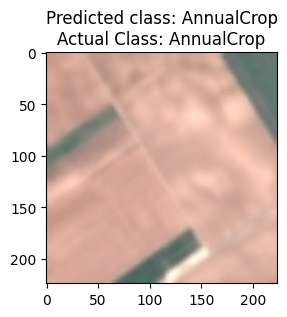

In [ ]:
# Retrieve sample image
index = 15
image, label = test_data[index]

# Predict on sample
model = model.to("cpu")
output = model(image.unsqueeze(0))
_, pred = torch.max(output, 1)

# Get corresponding class label
label = class_names[label]
pred = class_names[pred[0]]

# Visualize sample and prediction
image = image.cpu().numpy().transpose((1, 2, 0))
image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image)
ax.set_title("Predicted class: {}\nActual Class: {}".format(pred, label));

Here, we show how to run the model on a PIL image.

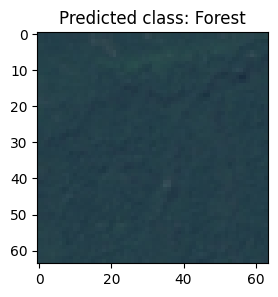

In [ ]:
from PIL import Image
image_path = './EuroSAT/2750/Forest/Forest_2.jpg'
image = Image.open(image_path)

# Transform image
input = test_transform(image)

# Predict on sample
output = model(input.unsqueeze(0))

# Get corresponding class label
_, pred = torch.max(output, 1)
pred = class_names[pred[0]]

# Visualize results
fig, ax = plt.subplots(figsize=(3,3))
ax.imshow(image)
ax.set_title("Predicted class: {}".format(pred));

<a name="exercises"></a>
# Exercise 1: Experiment with a different fine-tuning strategy.

So far, we've intialized the CNN with weights from a model train on the ImageNet data and retrained the model on the EuroSAT dataset by updating **all weights**. Another approach to fine-tuning involves using the pretrained convolutional layers as a fixed feature extractor and freezing those weights, only updating the weights of the final fully-connected layers for classification.

⭐Freeze all but the final layers of a ResNet50 model. How does this finetuning strategy compare against the previous strategy?

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Add final (unfrozen) layer for classification
model.fc = torch.nn.Linear(model.fc.in_features, len(dataset.classes))
model = model.to(device)

# Commence training
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)

Epoch 1


  0%|          | 0/1182 [00:00<?, ?it/s]

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Train Loss: 1.96; Accuracy: 45.78


  0%|          | 0/254 [00:00<?, ?it/s]

...

Val Loss: 1.05; Accuracy: 72.59
Epoch 10


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 0.95; Accuracy: 72.12


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 1.01; Accuracy: 72.02


# Exercise 2: Experiment with different Imagenet-pretrained CNN models.

ResNet50 is only one of many different CNN model architectures. Determining the best model architecture is an important part of the model selection process, and in practice, it's best to try out and compare different model architectures. A detailed description of pretrained CNN models supported in Pytorch can be found here: https://pytorch.org/vision/0.18/models.html


Make sure to modify the last layer for classification to match the number of classes (Hint: the number of classes = `len(dataset.classes)`).

Here we choose EfficientNet-B0 as the model to train and evaluate. More information on EfficientNets can be found [here](https://arxiv.org/pdf/1905.11946).

In [ ]:
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Modify the final layer for classification
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, len(dataset.classes))

model = model.to(device)
torchsummary.summary(model, (3, 224, 224))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
            Conv2d-4         [-1, 32, 112, 112]             288
       BatchNorm2d-5         [-1, 32, 112, 112]              64
              SiLU-6         [-1, 32, 112, 112]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 16, 112, 112]             512
      BatchNorm2d-14         [-1, 16, 1

In [ ]:
n_epochs = 5
lr = 0.001
# Commence training
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
best_model = fit(model, train_loader, val_loader, n_epochs, lr, criterion, optimizer)


Epoch 1


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 1.04; Accuracy: 70.65


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 0.76; Accuracy: 82.25
Epoch 2


...

Val Loss: 0.30; Accuracy: 91.56
Epoch 5


  0%|          | 0/1182 [00:00<?, ?it/s]

Train Loss: 0.54; Accuracy: 82.92


  0%|          | 0/254 [00:00<?, ?it/s]

Val Loss: 0.25; Accuracy: 93.28


Congrats on making it this far! Go to the next section, [Part 2: Automating Land Use and Land Cover Mapping using Python.](https://colab.research.google.com/drive/13I1wZT7thBlNdGA1tFQrK1MlRhMZMnpM?usp=sharing).

# Homework
Try to develop a more complicated neural network and increase the classification accuracy. Please try your best to see how good you can achieve.

### Standard answer
This answer follows the same steps as the lecture example:

1. **Data** – reuse the `train_loader`, `val_loader` and `test_loader` built in the lecture (same data augmentation, ImageNet normalization and 70/15/15 split).
2. **Model** – extend `SimpleCNN` into a deeper `AdvancedCNN`.
3. **Loss function and optimizer** – `CrossEntropyLoss` + optimizer.
4. **Training** – reuse the lecture's `train()` and `evaluate()` functions.
5. **Test set** – evaluate the best model on the held-out test set.
6. **Save and visualize** – save the model with `save_model()` and visualize a prediction, as in the *Results* section.

## Step 1: Data
We do **not** need to reload or re-split the data. Re-using the lecture's dataloaders guarantees that:
- the training set still uses **data augmentation** (`train_transform`), which reduces overfitting;
- the **test set stays untouched** during training, so the final test accuracy is a fair comparison with `SimpleCNN` and ResNet-50.

In [ ]:
# Re-use the dataloaders defined in the lecture
print("Train/val/test sizes: {}/{}/{}".format(len(train_loader.dataset), len(val_loader.dataset), len(test_loader.dataset)))
print("Number of classes: {}".format(len(class_names)))

## Step 2: Build a more complicated CNN
Compared with `SimpleCNN`, `AdvancedCNN` makes the following changes:

| Change | Why it helps |
|---|---|
| 3 convolution **blocks**, each with **2 conv layers** (32 → 64 → 128 filters) | Deeper network that learns richer features |
| `padding=1` in every conv layer | Keeps the spatial size, so only the pooling layers downsample |
| `BatchNorm2d` after each conv layer | Stabilizes and speeds up training |
| `Dropout2d` after each block and `Dropout` before the last layer | Reduces overfitting |

**Note:** In `SimpleCNN`, `fc1` is created inside `forward()` *after* the optimizer has been built, so its weights are never registered with the optimizer and are **never updated**. Here we compute `flatten_size` in `__init__` instead. Each `MaxPool2d(2, 2)` halves the image size, so after 3 poolings a 224×224 input becomes 128 × 28 × 28.

All layers, including the dropout layers, are defined in `__init__`, so `model.eval()` correctly turns dropout off during validation and testing.

In [ ]:
import copy
import torch
import torch.nn as nn

class AdvancedCNN(nn.Module):
    def __init__(self, num_classes=10, input_size=224):
        super(AdvancedCNN, self).__init__()

        # Block 1: 3 -> 32 channels
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.dropout1 = nn.Dropout2d(0.2)

        # Block 2: 32 -> 64 channels
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.dropout2 = nn.Dropout2d(0.3)

        # Block 3: 64 -> 128 channels
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout2d(0.4)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)  # Downsample by 2x

        # Feature map size after 3 poolings: 128 x (input_size/8) x (input_size/8)
        self.flatten_size = 128 * (input_size // 8) * (input_size // 8)

        # Fully connected layers
        self.fc1 = nn.Linear(self.flatten_size, 512)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)

        # Activation function
        self.relu = nn.ReLU()

    def forward(self, x):
        # Block 1
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # 224 -> 112
        x = self.dropout1(x)

        # Block 2
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))  # 112 -> 56
        x = self.dropout2(x)

        # Block 3
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.pool(self.relu(self.bn6(self.conv6(x))))  # 56 -> 28
        x = self.dropout3(x)

        # Classifier
        x = x.view(-1, self.flatten_size)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)

        return x

# Initialize the model
model = AdvancedCNN(num_classes=len(class_names), input_size=input_size)
model = model.to(device)
print(model)
torchsummary.summary(model, (3, input_size, input_size))

## Step 3: Define the loss function and optimizer
As in the lecture, we use cross-entropy loss. For a network trained **from scratch**, `Adam` usually converges much faster than plain `SGD` with `lr=0.001`. A small `weight_decay` (L2 regularization) further reduces overfitting.

In [ ]:
import torch.optim as optim

n_epochs = 15
lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

## Step 4: Train the model
We reuse the lecture's `train()` and `evaluate()` functions. The loop is the same as in `fit()`, with two additions:
- we record the loss and accuracy of every epoch so that we can plot learning curves;
- we save a **copy** of the best weights with `copy.deepcopy`. In `fit()`, `best_model = model` only stores a reference to the same model, so it always ends up holding the weights from the *last* epoch, not the best one.

In [ ]:
best_loss = np.inf
best_weights = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

# Train and validate over n_epochs
for epoch in range(n_epochs):
    print("Epoch {}".format(epoch+1))
    train_loss, train_acc = train(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(float(train_acc))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(float(val_acc))

    # Keep a copy of the weights with the lowest validation loss
    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = copy.deepcopy(model.state_dict())

# Load the best weights back into the model
model.load_state_dict(best_weights)
best_model = model
print("Training complete! Best validation loss: {:.4f}".format(best_loss))

In [ ]:
# Plot the learning curves
epochs_range = range(1, n_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].plot(epochs_range, history["train_loss"], label="Train")
axes[0].plot(epochs_range, history["val_loss"], label="Validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="Train")
axes[1].plot(epochs_range, history["val_acc"], label="Validation")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.show()

## Step 5: Model performance on the test set
Just as in the lecture, we use the best model to report the final accuracy on the **test set**, which the model has never seen. Compare this number with the test accuracy of `SimpleCNN` and ResNet-50.

In [ ]:
test_loss, test_acc = evaluate(best_model, test_loader, criterion, phase="test")

## Step 6: Save the model and visualize a prediction
We reuse `save_model()` and the visualization code from the *Results* section.

In [ ]:
hw_model_file = os.path.join(model_dir, 'best_advanced_cnn.pth')
save_model(best_model, hw_model_file)

In [ ]:
# Retrieve sample image
index = 15
image, label = test_data[index]

# Predict on sample
best_model.eval()
with torch.no_grad():
    output = best_model(image.unsqueeze(0).to(device))
_, pred = torch.max(output, 1)

# Get corresponding class label
label = class_names[label]
pred = class_names[pred[0]]

# Visualize sample and prediction
image = image.cpu().numpy().transpose((1, 2, 0))
image = np.clip(np.array(imagenet_std) * image + np.array(imagenet_mean), 0, 1)

fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(image)
ax.set_title("Predicted class: {}\nActual Class: {}".format(pred, label));

### Ideas to push the accuracy further
- Train for more epochs, and add a learning-rate scheduler (e.g. `optim.lr_scheduler.StepLR`).
- Add a 4th conv block, or replace the large `fc1` layer with global average pooling (`nn.AdaptiveAvgPool2d(1)`). This removes most of the ~51M parameters in `fc1` and reduces overfitting.
- Use transfer learning (ResNet-50 / EfficientNet from the exercises). Pre-trained models usually beat a CNN trained from scratch.

# References
- Helber, P., Bischke, B., Dengel, A., & Borth, D. (2019). Eurosat: A novel dataset and deep learning benchmark for land use and land cover classification. IEEE Journal of Selected Topics in Applied Earth Observations and Remote Sensing, 12(7), 2217-2226.
- Wang, Y., Braham, N. A. A., Xiong, Z., Liu, C., Albrecht, C. M., & Zhu, X. X. (2023). SSL4EO-S12: A large-scale multimodal, multitemporal dataset for self-supervised learning in Earth observation [Software and Data Sets]. IEEE Geoscience and Remote Sensing Magazine, 11(3), 98-106.